# EDA inicial - Cancelación de reservas

Este notebook analiza nulos, distribución de clases y variables clave para justificar el enfoque de modelado.

## Justificación de métricas

Se usa **AUC-ROC** como métrica principal porque el problema puede estar desbalanceado y AUC-ROC evalúa la capacidad discriminativa del modelo para todos los umbrales.

Además se reportan **accuracy, precision, recall y F1-score** para analizar costes de falsos positivos y falsos negativos.

## 1. Carga e inspección

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/raw/dataset_practica_final.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [32]:
# Mostrar las dimensiones del DataFrame
df.shape

# Tipos de datos de cada columna
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [33]:
# Información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## 2. Variable objetivo

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


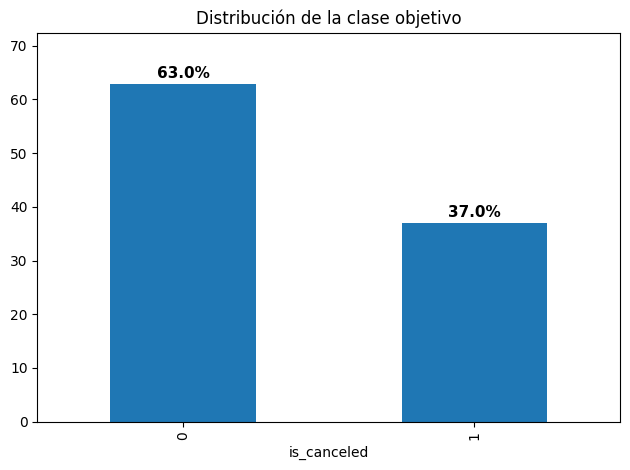

In [34]:
# Selección de la variable objetivo
target = df['is_canceled']

# Distribución de la clase objetivo 
print(target.value_counts())

# Distribución de la clase objetivo en porcentaje
print(target.value_counts(normalize=True) * 100)

# Visualización en porcentaje de la distribución de la clase objetivo
pcts = target.value_counts(normalize=True) * 100
ax = pcts.plot(kind='bar', title='Distribución de la clase objetivo')

for bar, pct in zip(ax.patches, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.ylim(0, pcts.max() * 1.15)
plt.tight_layout()
plt.show()


## 3. Valores nulos y duplicados

In [35]:
# Cuantos nulos hay en cada columna
nulos = df.isnull().sum()
pct_nulos = nulos / len(df) * 100
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% sobre total': pct_nulos.round(3)})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
print("Nulos por columna:")
print(resumen_nulos.to_string())

# Separador
print("=" * 50)

# Filas duplicadas
dup = df.duplicated().sum()
print(f"Filas duplicadas: {dup} ({dup / len(df) * 100:.2f}%)")


Nulos por columna:
           Nulos  % sobre total
company   112593         94.307
agent      16340         13.686
country      488          0.409
children       4          0.003
Filas duplicadas: 31994 (26.80%)


## 3.1 Tratamiento de valores nulos

In [36]:
df_clean = df.copy()

# children: 4 nulos: imputar con 0
df_clean['children'] = df_clean['children'].fillna(0)

# country: 488 nulos: imputar con 'Unknown'
df_clean['country'] = df_clean['country'].fillna('Unknown')

# Para evitar la alta cardinalidad en la columna "country", 
# se agrupan los países menos frecuentes en una categoría "Other". 
# Se identifican los 10 países más comunes y se reemplazan los 
# demás con "Other". Esto ayuda a reducir la cantidad de categorías 
# únicas y mejora la capacidad del modelo para generalizar.
top_countries = df_clean["country"].value_counts().nlargest(10).index
df_clean["country"] = df_clean["country"].where(
    df_clean["country"].isin(top_countries),
    "Other",
)

# agent: 16.340 nulos: el nulo significa "sin agente" (reserva directa)
# Se convierte en variable binaria más informativa que el ID numérico
df_clean['has_agent'] = df_clean['agent'].notnull().astype(int)
df_clean = df_clean.drop(columns=['agent'])

# company: 94.3% nulos: eliminar directamente
df_clean = df_clean.drop(columns=['company'])

## 3.2 Tratamiento de duplicados

In [37]:
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
n_after = len(df_clean)
print(f"Filas antes:           {n_before:,}")
print(f"Filas después:         {n_after:,}")

Filas antes:           119,390
Filas después:         87,144


## 3.3 Variables con data leakage

`reservation_status` y `reservation_status_date` revelan directamente el resultado que queremos predecir:

Incluirlas en el modelo sería hacer trampa: aprendería la etiqueta en lugar de los patrones de comportamiento del cliente. Las eliminamos de hacer cualquier análisis.

In [38]:
leakage_cols = ['reservation_status', 'reservation_status_date']
df_clean = df_clean.drop(columns=leakage_cols)

## 4. Estadísticas descriptivas

In [39]:
# Resumen estadístico de las columnas numéricas
df_clean.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,87144.0,0.275647,0.446842,0.00,0.0,0.0,1.0,1.0
lead_time,87144.0,79.798494,85.964677,0.00,11.0,49.0,125.0,737.0
arrival_date_year,87144.0,2016.210709,0.685982,2015.00,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,87144.0,26.830981,13.670349,1.00,16.0,27.0,37.0,53.0
arrival_date_day_of_month,87144.0,15.811347,8.837910,1.00,8.0,16.0,23.0,31.0
stays_in_weekend_nights,87144.0,1.005967,1.032553,0.00,0.0,1.0,2.0,19.0
stays_in_week_nights,87144.0,2.626825,2.055556,0.00,1.0,2.0,4.0,50.0
adults,87144.0,1.877284,0.626224,0.00,2.0,2.0,2.0,55.0
children,87144.0,0.139023,0.456460,0.00,0.0,0.0,0.0,10.0
babies,87144.0,0.010833,0.113660,0.00,0.0,0.0,0.0,10.0


Podemos observar que el mínimo de ``adr`` es negativo. Al tratarse de un campo que muestra el precio noche es algo imposible y seguramente se trate de un error al introducir los datos, para asegurarnos de que no influya en el entrenamiento nos encargamos de eliminarlo

In [40]:
df_clean = df_clean[df_clean['adr'] >= 0]

In [45]:
# Comprbamos que no hay valores negativos en 'adr'
print(f"Valores negativos en 'adr': {(df_clean['adr'] < 0).sum()}")

# Comproamos las estadísticas de 'adr' para detectar posibles outliers
df_clean['adr'].describe().transpose()

Valores negativos en 'adr': 0


count    87143.000000
mean       106.369552
std         55.066126
min          0.000000
25%         72.000000
50%         98.100000
75%        134.100000
max       5400.000000
Name: adr, dtype: float64

In [46]:
# Resumen estadístico de las columnas categóricas
df_clean.describe(include='object').transpose()

,count,unique,top,freq
hotel,87143,2,City Hotel,53197
arrival_date_month,87143,12,August,11247
meal,87143,5,BB,67749
country,87143,11,PRT,27442
market_segment,87143,8,Online TA,51575
distribution_channel,87143,5,TA/TO,68965
reserved_room_type,87143,10,A,56313
assigned_room_type,87143,12,A,46109
deposit_type,87143,3,No Deposit,85998
customer_type,87143,4,Transient,71910


## 5. Distribuciones de variables numéricas

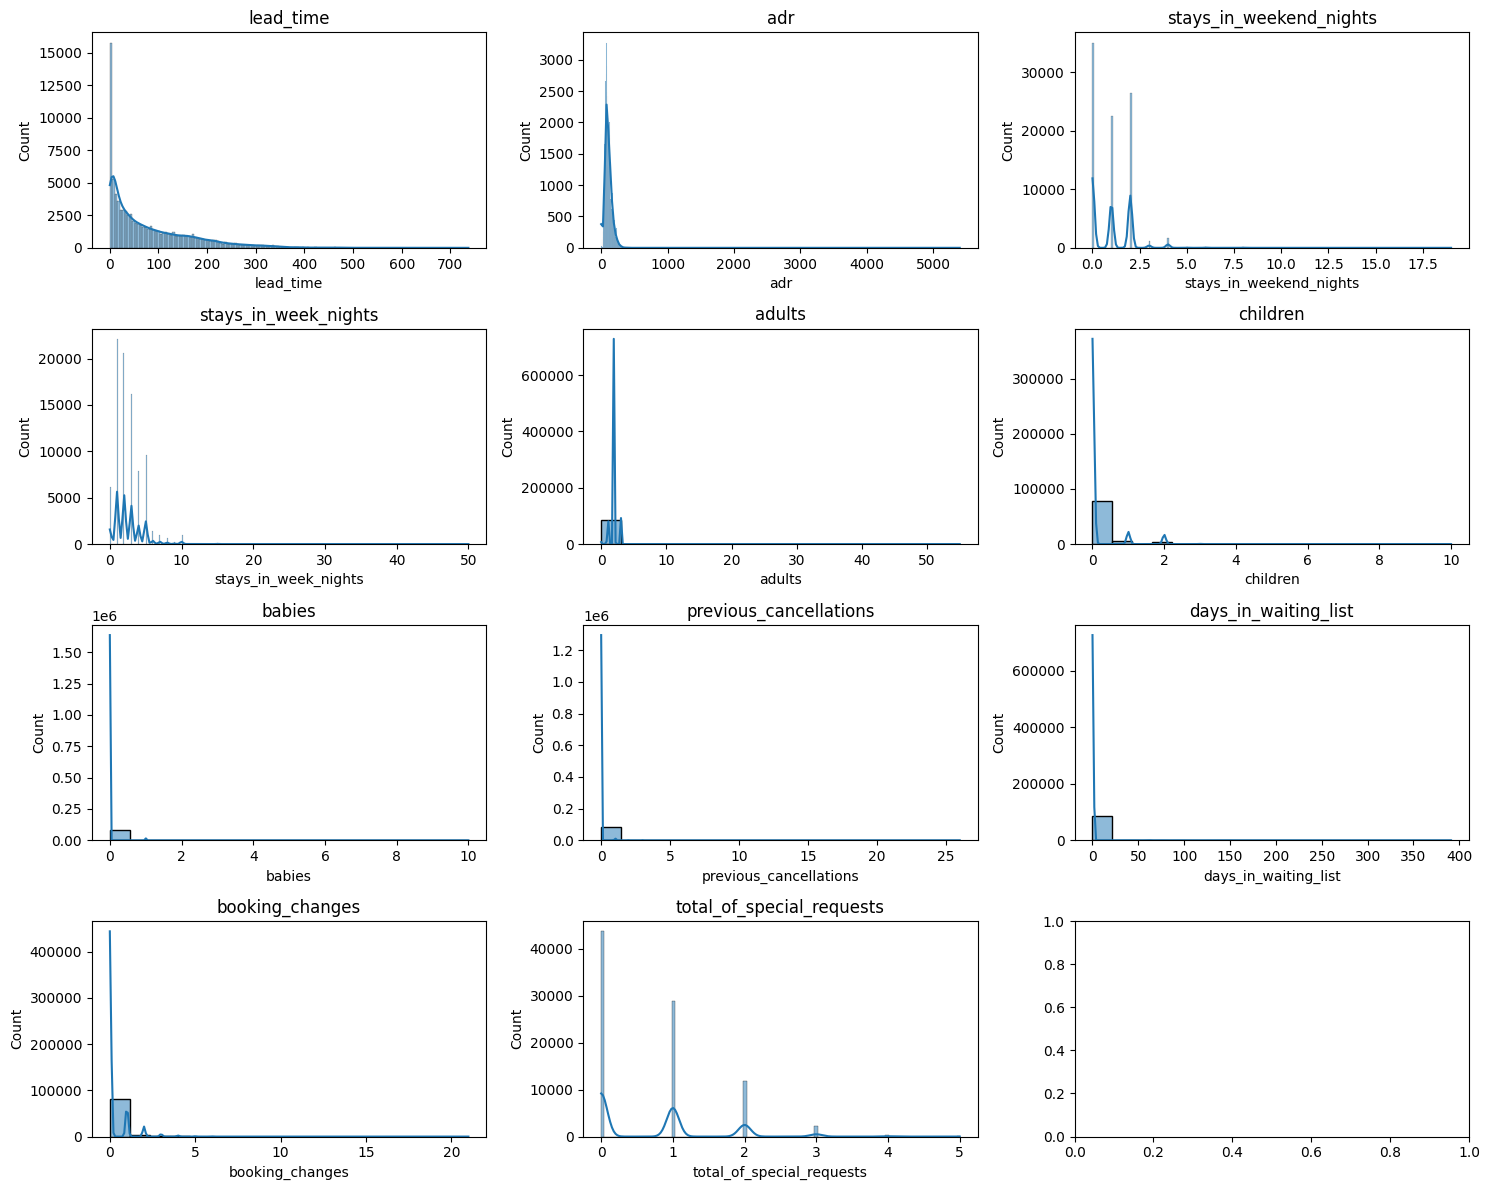

In [47]:
# Visualización de la distribución de las variables numéricas
cols_to_plot = [
    'lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'days_in_waiting_list', 'booking_changes', 'total_of_special_requests'
]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df_clean[col], ax=axes[i], kde=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


## 6. Variables categóricas

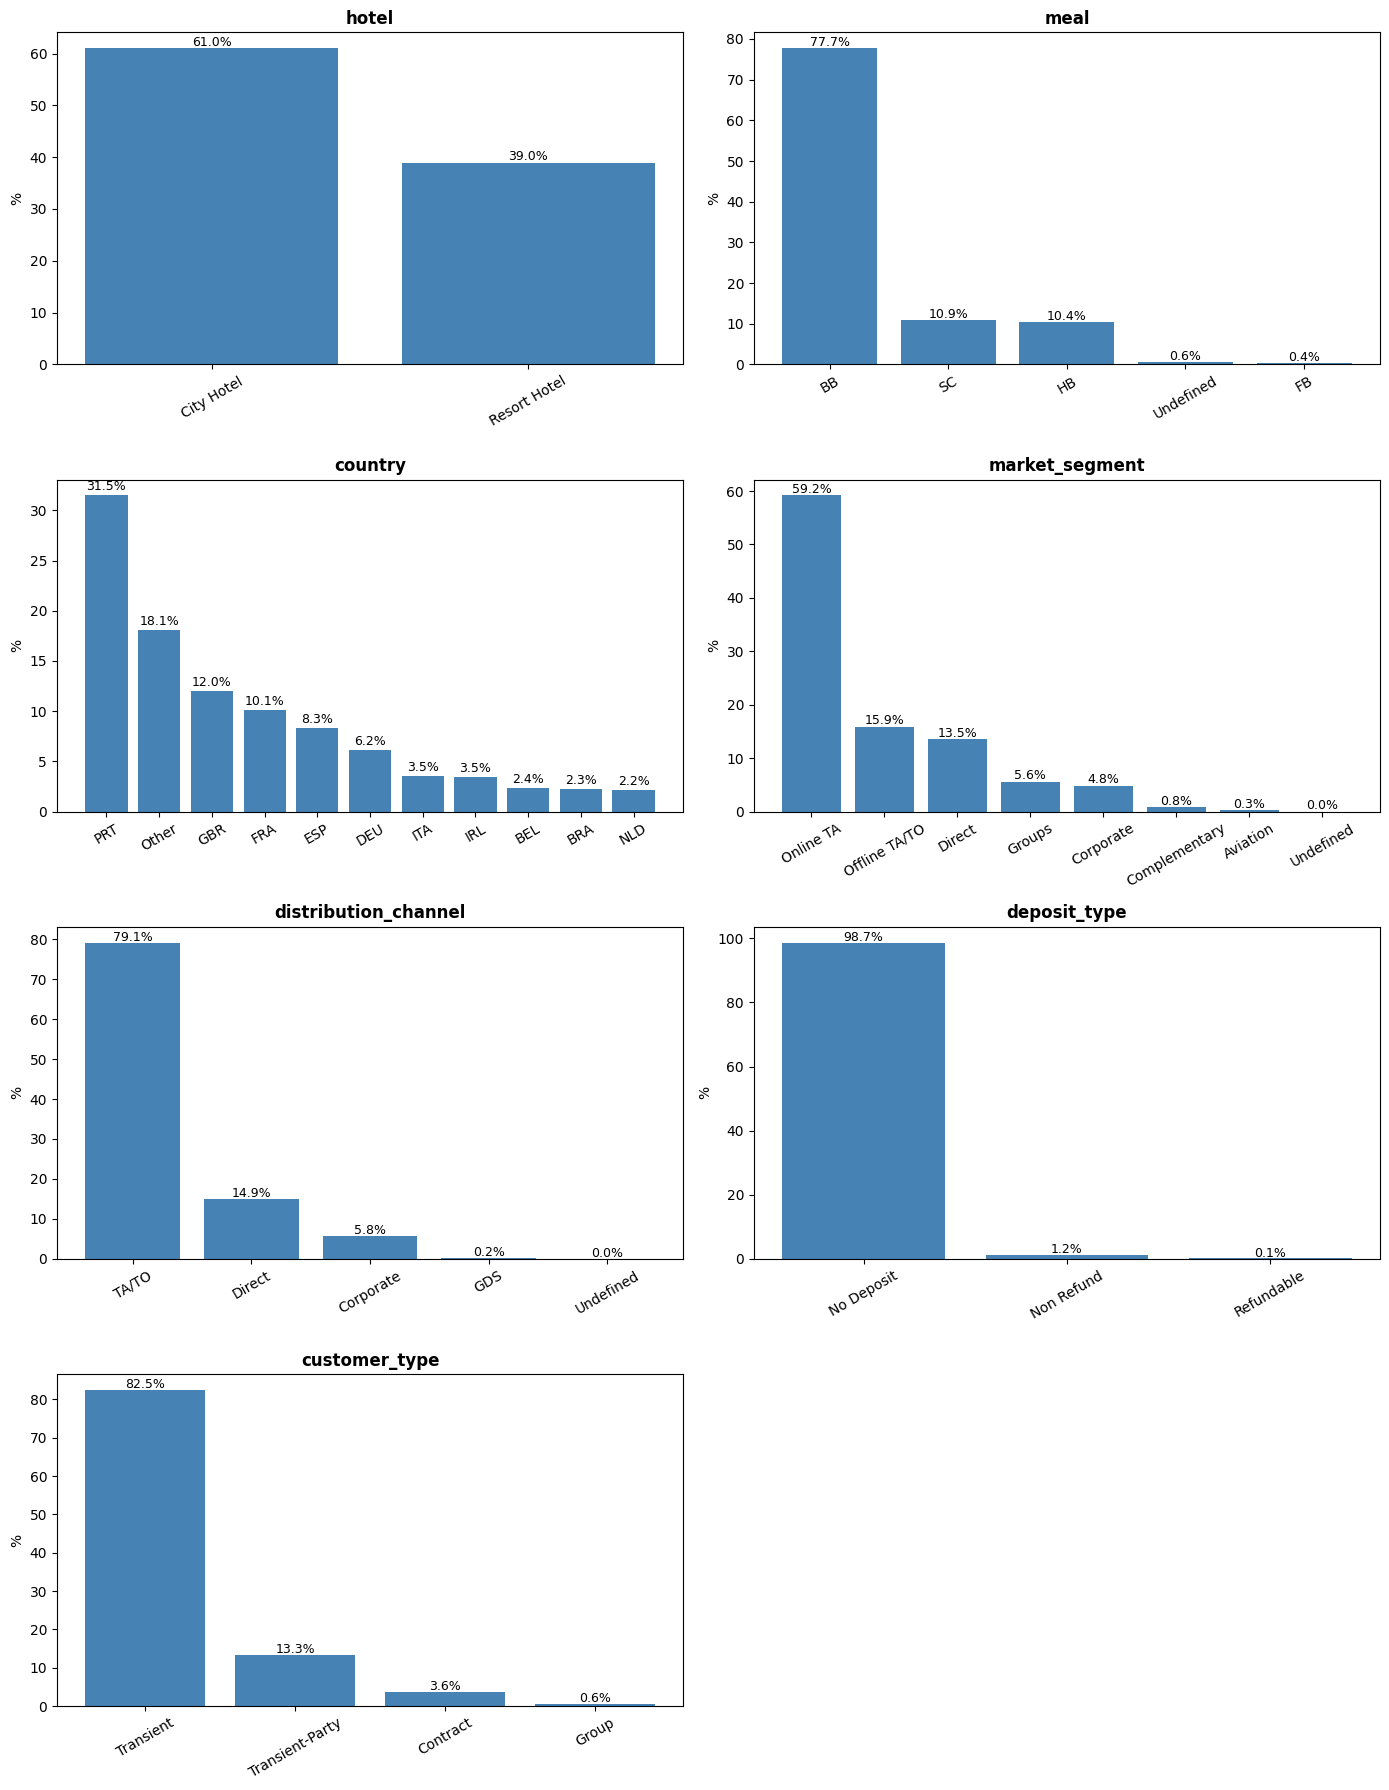

In [51]:
cat_vars = ['hotel', 'meal', 'country', 'market_segment',
            'distribution_channel', 'deposit_type', 'customer_type']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for ax, col in zip(axes, cat_vars):
    counts = df_clean[col].value_counts()
    pcts = counts / counts.sum() * 100
    bars = ax.bar(counts.index, pcts.values, color='steelblue')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', fontsize=9)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Correlaciones

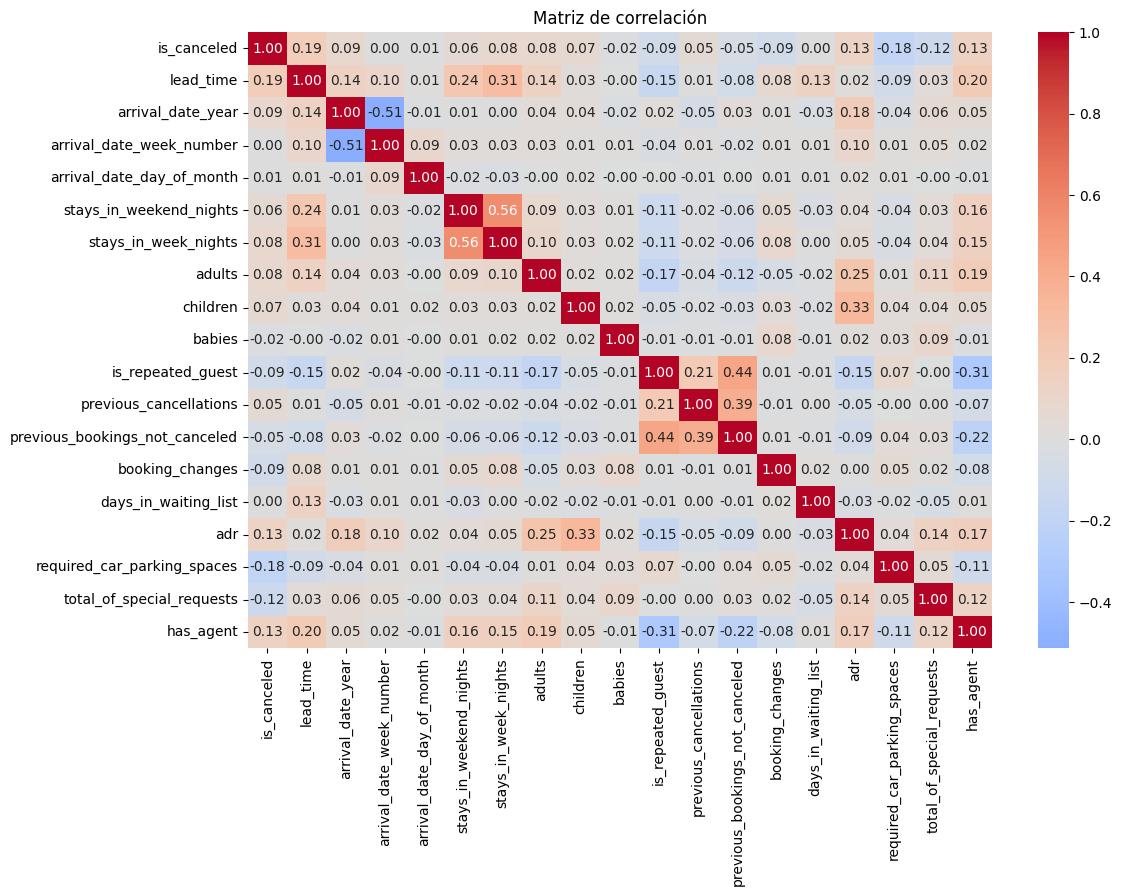

In [49]:
# Matriz de correlación para variables numéricas
corr_matrix = df_clean.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()
